## BƯỚC 1: Nạp thư viện, chọn nguồn dữ liệu và khởi tạo nhật ký.

In [1]:
# BƯỚC 1: Nạp thư viện, chọn nguồn dữ liệu và khởi tạo nhật ký.
from pathlib import Path
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn

TARGET = "anomaly"  # Tên nhãn phân loại cần tách riêng khỏi feature.
MISSING_CATEGORY = "__MISSING__"  # Mã category thay cho giá trị phân loại bị thiếu.
UNKNOWN_CATEGORY = "__UNKNOWN__"  # Mã category dành cho giá trị test chưa thấy ở train.
STEP_LOG = []  # Lưu thống kê thay đổi theo thứ tự các bước chạy.

# Tìm thư mục data cạnh notebook hoặc tại thư mục cha nếu chạy từ thư mục con.
DATA_DIR = next(
    (path for path in (Path.cwd() / "data", Path.cwd().parent / "data") if path.is_dir()),
    None,
)
if DATA_DIR is None:  # Dừng ngay nếu không xác định được nơi chứa dữ liệu.
    raise FileNotFoundError("Không tìm thấy thư mục data/ từ thư mục làm việc hiện tại.")

TRAIN_PATH = DATA_DIR / "train_features.csv"
TEST_PATH = DATA_DIR / "test_features.csv"

PROCESSED_DIR = DATA_DIR / "processed"  # Thư mục dành cho dữ liệu đã xử lý và log.
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)  # Tạo thư mục nếu đây là lần chạy đầu.


def record_step(step, train_before, train_after, test_before, test_after,
                train_affected=0, test_affected=0, train_values_changed=0,
                test_values_changed=0, columns_added=0):
    """Ghi row count, số dòng bị tác động và số giá trị/cột thay đổi."""
    entry = {
        "step": step,  # Tên công đoạn để đọc log.
        "train_rows_before": train_before,  # Số dòng train trước công đoạn.
        "train_rows_after": train_after,  # Số dòng train sau công đoạn.
        "train_rows_added": max(train_after - train_before, 0),  # Số dòng train mới thêm.
        "train_rows_removed": max(train_before - train_after, 0),  # Số dòng train bị loại.
        "train_rows_affected": train_affected,  # Số dòng train có ít nhất một thay đổi.
        "train_values_changed": train_values_changed,  # Số ô train được sửa hoặc tạo.
        "test_rows_before": test_before,  # Số dòng test trước công đoạn.
        "test_rows_after": test_after,  # Số dòng test sau công đoạn.
        "test_rows_added": max(test_after - test_before, 0),  # Số dòng test mới thêm.
        "test_rows_removed": max(test_before - test_after, 0),  # Số dòng test bị loại.
        "test_rows_affected": test_affected,  # Số dòng test có ít nhất một thay đổi.
        "test_values_changed": test_values_changed,  # Số ô test được sửa hoặc tạo.
        "columns_added": columns_added,  # Số cột mới sinh trong bước.
    }
    STEP_LOG[:] = [previous for previous in STEP_LOG if previous["step"] != step]  # Thay bản ghi cũ nếu chạy lại cùng bước.
    STEP_LOG.append(entry)  # Lưu bản ghi mới vào cuối nhật ký.
    from IPython.display import display, HTML
    col_change = entry.get('columns_added', entry.get('columns_removed', 0))
    if 'columns_removed' in entry and col_change > 0: col_change = -col_change
    
    col_str = f"<span style='color:green; font-weight:bold'>+{col_change}</span>" if col_change > 0 else (f"<span style='color:red; font-weight:bold'>{col_change}</span>" if col_change < 0 else "<span style='color:gray'>0</span>")
    
    html = (f"<b>Bước:</b> {step} | "
            f"<b>Train:</b> <span style='color:green; font-weight:bold'>+{entry['train_rows_added']}</span> / <span style='color:red; font-weight:bold'>-{entry['train_rows_removed']}</span> / <span style='color:blue; font-weight:bold'>~{entry['train_rows_affected']}</span> dòng | "
            f"<b>Test:</b> <span style='color:green; font-weight:bold'>+{entry['test_rows_added']}</span> / <span style='color:red; font-weight:bold'>-{entry['test_rows_removed']}</span> / <span style='color:blue; font-weight:bold'>~{entry['test_rows_affected']}</span> dòng | "
            f"<b>Cột:</b> {col_str}")
    display(HTML(html))

print(f"Đã chọn: {TRAIN_PATH.name}, {TEST_PATH.name}")  # Xác nhận hai file nguồn được sử dụng.
print("Sẵn sàng nạp và xử lý dữ liệu bằng pandas.")

Đã chọn: train_features.csv, test_features.csv
Sẵn sàng nạp và xử lý dữ liệu bằng pandas.


## BƯỚC 2: Nạp trực tiếp CSV bằng pandas.

In [2]:
# BƯỚC 2: Nạp trực tiếp CSV bằng pandas.
import time

load_started_at = time.perf_counter()  # Bắt đầu đo thời gian đọc CSV.
train_raw = pd.read_csv(TRAIN_PATH, low_memory=False)  # Nạp train trực tiếp, suy luận kiểu nhất quán trên toàn file.
test_raw = pd.read_csv(TEST_PATH, low_memory=False)  # Nạp test trực tiếp theo cùng cách.
TRAIN_ROWS_INITIAL = len(train_raw)  # Lưu số dòng ban đầu để so sánh toàn pipeline.
TEST_ROWS_INITIAL = len(test_raw)  # Lưu số dòng test ban đầu.

record_step("Nạp CSV bằng pandas", TRAIN_ROWS_INITIAL, TRAIN_ROWS_INITIAL,  # Log bước nạp không đổi số dòng.
            TEST_ROWS_INITIAL, TEST_ROWS_INITIAL)  # Ghi số dòng test trước/sau bằng nhau.
print(f"Train: {train_raw.shape}")  # Hiển thị kích thước train vừa nạp.
print(f"Test:  {test_raw.shape}")  # Hiển thị kích thước test vừa nạp.
print(f"Thời gian đọc CSV bằng pandas: {time.perf_counter() - load_started_at:.1f} giây")  # Báo thời gian nạp trực tiếp.

Train: (1749494, 57)
Test:  (1800567, 57)
Thời gian đọc CSV bằng pandas: 31.6 giây


## BƯỚC 3: Kiểm tra schema và nhãn trước khi xử lý.

In [3]:
# BƯỚC 3: Kiểm tra schema và nhãn trước khi xử lý.
if TARGET not in train_raw.columns:  # Train bắt buộc có target để huấn luyện supervised.
    raise KeyError(f"Không tìm thấy cột nhãn {TARGET!r} trong train.")  # Dừng nếu chọn nhầm file/schema.

if train_raw[TARGET].isna().any():  # Target thiếu không thể dùng để học hoặc đánh giá.
    raise ValueError(f"Cột nhãn {TARGET!r} có giá trị thiếu.")  # Báo lỗi trước khi tách X/y.

print("Cột train-only:", sorted(set(train_raw.columns) - set(test_raw.columns)))  # Liệt kê cột chỉ có ở train, thường gồm target.
print("Cột test-only:", sorted(set(test_raw.columns) - set(train_raw.columns)))  # Liệt kê cột chỉ có ở test, thường gồm row_id.
print("Nhãn train:")  # Đặt nhãn cho bảng phân bố lớp tiếp theo.
print(train_raw[TARGET].value_counts(dropna=False).sort_index())  # Đếm số dòng của từng lớp anomaly.

Cột train-only: ['anomaly']
Cột test-only: ['row_id']
Nhãn train:
anomaly
0    1712198
1      37296
Name: count, dtype: int64


## BƯỚC 4: EDA ban đầu bằng histogram, missing/class chart và lịch sử theo ngày.

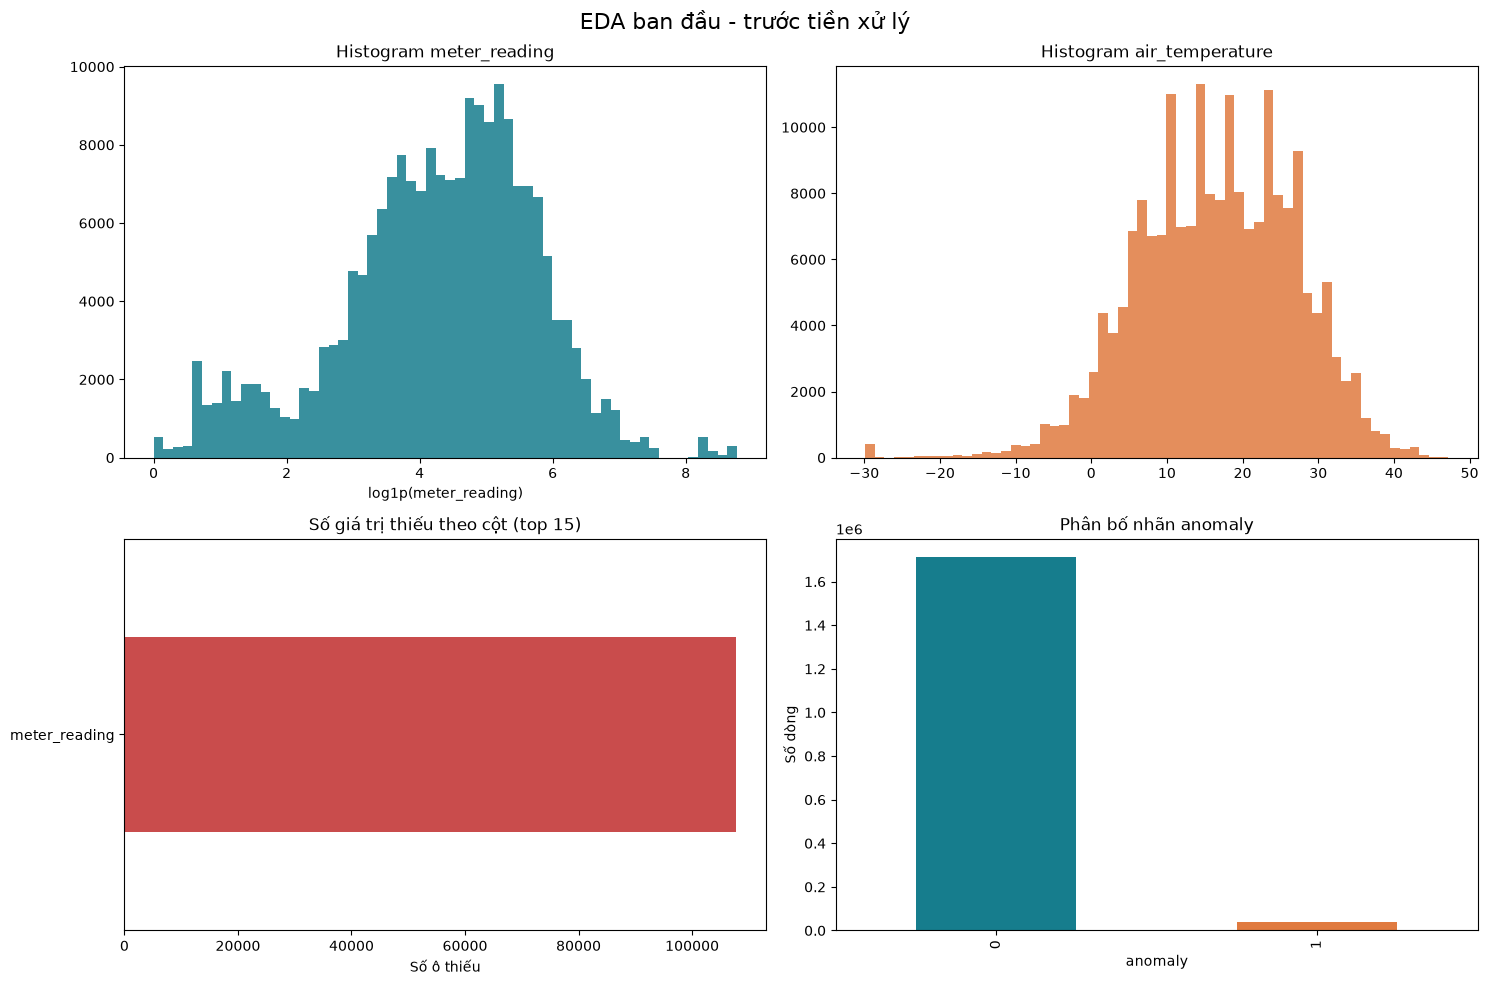

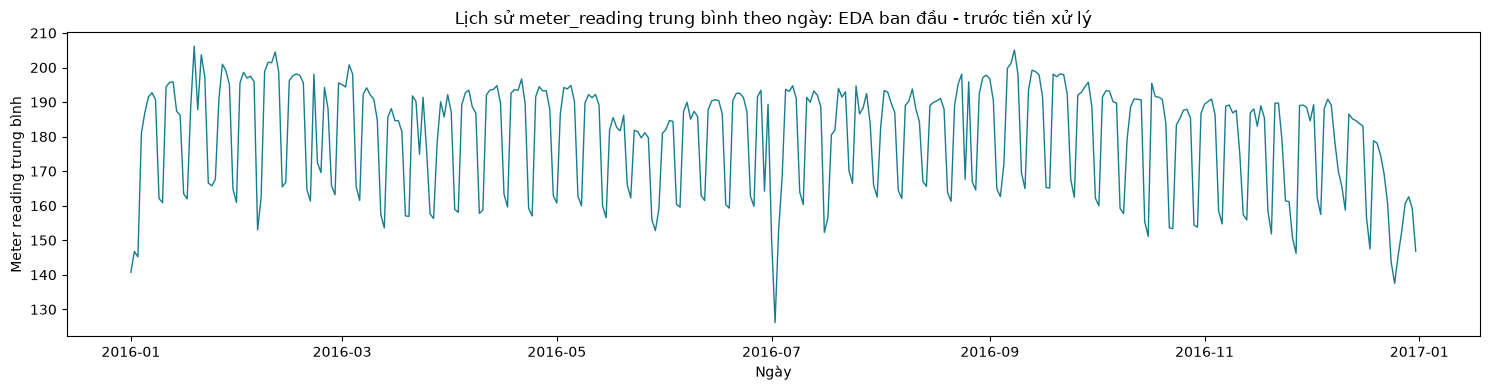

Số dòng trùng nguyên bản train: 0
Số ô thiếu nguyên bản train: 107,653

--- THÔNG TIN CỘT VÀ DỮ LIỆU THIẾU SAU EDA BAN ĐẦU ---
Tất cả các cột dữ liệu:
['building_id', 'timestamp', 'meter_reading', 'anomaly', 'site_id', 'primary_use', 'square_feet', 'year_built', 'floor_count', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'air_temperature_mean_lag7', 'air_temperature_max_lag7', 'air_temperature_min_lag7', 'air_temperature_std_lag7', 'air_temperature_mean_lag73', 'air_temperature_max_lag73', 'air_temperature_min_lag73', 'air_temperature_std_lag73', 'hour', 'weekday', 'month', 'year', 'weekday_hour', 'hour_x', 'hour_y', 'month_x', 'month_y', 'weekday_x', 'weekday_y', 'building_weekday_hour', 'building_weekday', 'building_month', 'building_hour', 'building_meter', 'is_holiday', 'gte_hour', 'gte_weekday', 'gte_month', 'gte_building_id', 'gte_primary_use', 'gte_site_id', 'gte_meter', 'gte_meter_hour', 'gte_

In [4]:
# BƯỚC 4: EDA ban đầu bằng histogram, missing/class chart và lịch sử theo ngày.
def plot_eda_snapshot(frame, stage):  # Dùng chung cho EDA trước/sau xử lý mà không sửa bảng đầu vào.
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))  # Tạo dashboard 4 biểu đồ trên một figure.
    axes = axes.ravel()  # Làm phẳng mảng axes để truy cập lần lượt bằng chỉ số.

    if "meter_reading" in frame.columns:  # Chỉ vẽ histogram khi có biến đo năng lượng.
        reading = pd.to_numeric(frame["meter_reading"], errors="coerce").dropna()  # Ép số và bỏ null chỉ trong dữ liệu dùng vẽ.
        if len(reading) > 200_000:  # Giới hạn điểm vẽ để không làm chậm notebook.
            reading = reading.sample(n=200_000, random_state=42)  # Lấy mẫu tái lập; không thay đổi dữ liệu gốc.
        if len(reading) and reading.min() >= 0:  # log1p chỉ phù hợp khi giá trị không âm.
            reading = np.log1p(reading)  # Nén đuôi phân phối để histogram dễ quan sát hơn.
            reading_label = "log1p(meter_reading)"  # Ghi rõ trục đã biến đổi chỉ để hiển thị.
        else:  # Giữ nguyên thang đo khi có giá trị âm hoặc không có điểm.
            reading_label = "meter_reading"  # Gắn nhãn trục đúng với dữ liệu vẽ.
        axes[0].hist(reading, bins=60, color="#167D8D", alpha=0.85)  # Vẽ phân phối meter_reading.
        axes[0].set_title("Histogram meter_reading")  # Đặt tiêu đề cho biểu đồ thứ nhất.
        axes[0].set_xlabel(reading_label)  # Nêu rõ cách biến đổi trục x nếu có.
    else:  # Giữ bố cục dashboard kể cả khi dataset khác thiếu cột này.
        axes[0].text(0.5, 0.5, "Không có meter_reading", ha="center")  # Thay histogram bằng ghi chú.

    second_numeric = next(  # Tìm biến số phụ để xem phân phối/ngoại lệ.
        (column for column in ("air_temperature", "square_feet", "wind_speed")  # Ưu tiên thời tiết rồi đến diện tích/gió.
         if column in frame.columns),  # Chỉ chọn biến thật sự có trong bảng.
        None,  # Dùng None nếu không có biến phù hợp.
    )
    if second_numeric:  # Vẽ biến phụ nếu đã tìm được.
        values = pd.to_numeric(frame[second_numeric], errors="coerce").dropna()  # Chuyển về số và bỏ null cho phần vẽ.
        if len(values) > 200_000:  # Giữ số điểm vẽ ở mức hợp lý.
            values = values.sample(n=200_000, random_state=42)  # Lấy mẫu ổn định giữa các lần chạy.
        axes[1].hist(values, bins=60, color="#E07A3F", alpha=0.85)  # Vẽ histogram biến phụ.
        axes[1].set_title(f"Histogram {second_numeric}")  # Ghi tên biến đang được hiển thị.
    else:  # Trường hợp không có cột số phụ.
        axes[1].text(0.5, 0.5, "Không có biến số thứ hai", ha="center")  # Báo rõ biểu đồ bị bỏ qua.

    missing = frame.isna().sum().sort_values(ascending=False)  # Đếm null trên từng cột và xếp nhiều trước.
    missing = missing[missing.gt(0)].head(15).sort_values()  # Chỉ giữ tối đa 15 cột có null để biểu đồ gọn.
    if len(missing):  # Có missing thì vẽ số ô thiếu.
        missing.plot.barh(ax=axes[2], color="#C94C4C")  # Vẽ thanh ngang cho dễ so sánh cột.
        axes[2].set_title("Số giá trị thiếu theo cột (top 15)")  # Đặt tiêu đề biểu đồ missing.
        axes[2].set_xlabel("Số ô thiếu")  # Ghi ý nghĩa trục số lượng.
    else:  # Không có null trong bảng đang phân tích.
        axes[2].text(0.5, 0.5, "Không có giá trị thiếu", ha="center", va="center")  # Hiển thị trạng thái rỗng.
        axes[2].set_title("Missing values")  # Giữ tiêu đề nhất quán giữa hai lần EDA.

    if TARGET in frame.columns:  # Chỉ vẽ class distribution khi bảng có nhãn.
        frame[TARGET].value_counts(dropna=False).sort_index().plot.bar(  # Đếm từng lớp và vẽ cột.
            ax=axes[3], color=["#167D8D", "#E07A3F"]  # Dùng cùng màu lớp giữa các lần EDA.
        )
        axes[3].set_title("Phân bố nhãn anomaly")  # Nêu đây là biểu đồ nhãn.
        axes[3].set_xlabel(TARGET)  # Ghi tên biến nhãn trên trục x.
        axes[3].set_ylabel("Số dòng")  # Ghi số lượng mẫu trên trục y.
    else:  # Test hoặc bảng không nhãn vẫn giữ vị trí biểu đồ.
        axes[3].text(0.5, 0.5, "Không có nhãn để kiểm tra", ha="center", va="center")  # Báo không có target.

    fig.suptitle(stage, fontsize=16)  # Gắn nhãn EDA trước/sau lên dashboard.
    fig.tight_layout()  # Tự căn lề để tiêu đề và axes không chồng nhau.
    plt.show()  # Render dashboard trong notebook.

    if "timestamp" in frame.columns and "meter_reading" in frame.columns:  # Vẽ lịch sử nếu đủ thời gian và giá trị đo.
        dates = pd.to_datetime(frame["timestamp"], errors="coerce").dt.floor("D")  # Quy timestamp về ngày.
        readings = pd.to_numeric(frame["meter_reading"], errors="coerce")  # Đảm bảo số đo ở dạng numeric.
        daily_mean = readings.groupby(dates).mean().dropna().sort_index()  # Tính trung bình ngày và bỏ ngày rỗng.
        fig, ax = plt.subplots(figsize=(15, 4))  # Tạo figure riêng để xem xu hướng thời gian.
        ax.plot(daily_mean.index, daily_mean.values, color="#167D8D", linewidth=1)  # Vẽ mức meter_reading theo ngày.
        ax.set_title(f"Lịch sử meter_reading trung bình theo ngày: {stage}")  # Gắn tên giai đoạn EDA.
        ax.set_xlabel("Ngày")  # Ghi trục thời gian.
        ax.set_ylabel("Meter reading trung bình")  # Ghi thống kê được vẽ.
        fig.tight_layout()  # Căn lề biểu đồ lịch sử.
        plt.show()  # Render time-history plot.

plot_eda_snapshot(train_raw, "EDA ban đầu - trước tiền xử lý")  # Vẽ baseline trước mọi thay đổi.
print(f"Số dòng trùng nguyên bản train: {int(train_raw.duplicated().sum()):,}")  # Đếm duplicate nguyên dòng.
print(f"Số ô thiếu nguyên bản train: {int(train_raw.isna().sum().sum()):,}")  # Đếm toàn bộ null làm baseline.

print("\n--- THÔNG TIN CỘT VÀ DỮ LIỆU THIẾU SAU EDA BAN ĐẦU ---")
print("Tất cả các cột dữ liệu:")
print(train_raw.columns.tolist())
print("\nSố lượng null/NA ở từng cột:")
print(train_raw.isna().sum())

record_step("EDA ban đầu (không biến đổi dữ liệu)", TRAIN_ROWS_INITIAL, TRAIN_ROWS_INITIAL,  # Ghi EDA nhưng đánh dấu không biến đổi train.
            TEST_ROWS_INITIAL, TEST_ROWS_INITIAL)  # Ghi tương tự cho test.

## BƯỚC 5: Tách nhãn/ID ra khỏi ma trận feature.

In [5]:
train_rows_before = len(train_raw)  # Chốt row count train trước khi chia X/y.
test_rows_before = len(test_raw)  # Chốt row count test trước khi lấy row_id.
y_train = pd.to_numeric(train_raw[TARGET], errors="raise").reset_index(drop=True)  # Lấy anomaly làm nhãn số và đặt index liên tục.
test_row_ids = test_raw["row_id"].reset_index(drop=True).copy() if "row_id" in test_raw else None  # Giữ ID test để ghép submission.

X_train = train_raw.drop(columns=[TARGET, "row_id"], errors="ignore").copy()  # Bỏ nhãn/ID khỏi feature train.
X_test = test_raw.drop(columns=[TARGET, "row_id"], errors="ignore").copy()  # Bỏ ID/nhãn nếu có khỏi feature test.

record_step("Tách nhãn và row_id", train_rows_before, len(X_train),  # Ghi số dòng X train trước/sau thao tác.
            test_rows_before, len(X_test))  # Ghi số dòng X test trước/sau.
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")  # Xác nhận số dòng X khớp y.
print(f"X_test: {X_test.shape} | Có row_id: {test_row_ids is not None}")  # Xác nhận kích thước và ID test.

# Chỉ giữ X/y/ID cần cho phần sau để giải phóng bảng thô lớn.
del train_raw, test_raw  # Xóa hai DataFrame gốc sau khi đã tách dữ liệu.
gc.collect()  # Yêu cầu Python thu gom bộ nhớ vừa giải phóng.

X_train: (1749494, 56) | y_train: (1749494,)
X_test: (1800567, 56) | Có row_id: True


16278

## BƯỚC 6: Chuẩn hóa timestamp thành datetime, chưa tạo feature lịch.

In [6]:
train_rows = len(X_train)  # Lưu row count train để log biến động.
test_rows = len(X_test)  # Lưu row count test để log biến động.
train_time_before = X_train["timestamp"].copy() if "timestamp" in X_train else None  # Giữ bản gốc để biết cột có cần parse không.
test_time_before = X_test["timestamp"].copy() if "timestamp" in X_test else None  # Kiểm tra riêng timestamp test.

if train_time_before is not None:  # Chỉ parse khi nguồn train có timestamp.
    X_train["timestamp"] = pd.to_datetime(X_train["timestamp"], errors="coerce")  # Giá trị lỗi được chuyển thành NaT để đếm.
if test_time_before is not None:  # Chỉ parse khi nguồn test có timestamp.
    X_test["timestamp"] = pd.to_datetime(X_test["timestamp"], errors="coerce")  # Dùng cùng kiểu datetime cho test.

train_time_converted = int(X_train["timestamp"].notna().sum()) if "timestamp" in X_train else 0  # Đếm timestamp train parse thành công.
test_time_converted = int(X_test["timestamp"].notna().sum()) if "timestamp" in X_test else 0  # Đếm timestamp test parse thành công.
train_bad_time = int(X_train["timestamp"].isna().sum()) if "timestamp" in X_train else 0  # Đếm NaT train để phát hiện lỗi định dạng.
test_bad_time = int(X_test["timestamp"].isna().sum()) if "timestamp" in X_test else 0  # Đếm NaT test.

record_step("Chuẩn hóa timestamp (giữ để feature engineering)", train_rows, len(X_train),  # Log row count train không đổi.
            test_rows, len(X_test), train_affected=train_time_converted,  # Ghi số dòng train có timestamp hợp lệ.
            test_affected=test_time_converted, train_values_changed=train_time_converted,  # Ghi số timestamp train được parse.
            test_values_changed=test_time_converted)  # Ghi số timestamp test được parse.
print(f"Timestamp không parse được: train={train_bad_time:,}, test={test_bad_time:,}")  # Báo dữ liệu thời gian lỗi.

Timestamp không parse được: train=0, test=0


## BƯỚC 7: Đồng bộ feature train/test và phân nhóm kiểu dữ liệu.

In [7]:
train_rows_before = len(X_train)  # Chốt số dòng train trước khi căn schema.
test_rows_before = len(X_test)  # Chốt số dòng test trước khi căn schema.
train_cols_before = set(X_train.columns)  # Lưu schema ban đầu phía train để tìm cột thiếu.
test_cols_before = set(X_test.columns)  # Lưu schema ban đầu phía test.
feature_columns = list(dict.fromkeys([*X_train.columns, *X_test.columns]))  # Hợp hai schema, giữ thứ tự xuất hiện đầu tiên.
train_added_columns = set(feature_columns) - train_cols_before  # Tìm cột test có nhưng train chưa có.
test_added_columns = set(feature_columns) - test_cols_before  # Tìm cột train có nhưng test chưa có.

X_train = X_train.reindex(columns=feature_columns)  # Thêm/căn cột train theo schema chung; cột mới sẽ là NaN.
X_test = X_test.reindex(columns=feature_columns)  # Căn test theo cùng thứ tự cột.
numeric_columns = X_train.select_dtypes(include="number").columns.tolist()  # Nhận diện cột số để điền thiếu ở bước tới.
# Giữ timestamp lại cho feature engineering; không biến datetime thành category.
categorical_columns = [  # Tạo danh sách cột category cần chuẩn hóa.
    column for column in feature_columns  # Duyệt mọi cột trong schema chung.
    if column not in numeric_columns and column != "timestamp"  # Loại số và timestamp khỏi nhóm category.
]

train_new_cells = len(X_train) * len(train_added_columns)  # Ước tính số ô NaN tạo ở train do cột mới.
test_new_cells = len(X_test) * len(test_added_columns)  # Ước tính số ô NaN tạo ở test.
record_step("Đồng bộ cột train/test", train_rows_before, len(X_train),  # Ghi row count train trước/sau.
            test_rows_before, len(X_test),  # Ghi row count test trước/sau.
            train_affected=len(X_train) if train_added_columns else 0,  # Mọi dòng train bị ảnh hưởng nếu thêm cột.
            test_affected=len(X_test) if test_added_columns else 0,  # Mọi dòng test bị ảnh hưởng nếu thêm cột.
            train_values_changed=train_new_cells, test_values_changed=test_new_cells,  # Ghi số ô NaN vừa tạo.
            columns_added=len(train_added_columns) + len(test_added_columns))  # Đếm tổng cột cần căn thêm.
print(f"Feature số: {len(numeric_columns)} | Category: {len(categorical_columns)}")  # Báo số cột theo nhóm dtype.
print(f"Cột train-only: {sorted(train_cols_before - test_cols_before)}")  # Hiển thị cột lệch phía train.
print(f"Cột test-only: {sorted(test_cols_before - train_cols_before)}")  # Hiển thị cột lệch phía test.

Feature số: 48 | Category: 7
Cột train-only: []
Cột test-only: []


## BƯỚC 8: Loại bỏ các feature không phù hợp và thêm cờ missing.

In [8]:
train_rows_before = len(X_train)
test_rows_before = len(X_test)
import numpy as np

# 1. Thêm cờ meter_reading_was_missing trước khi điền khuyết
X_train['meter_reading_was_missing'] = X_train['meter_reading'].isna().astype(np.int8)
X_test['meter_reading_was_missing'] = X_test['meter_reading'].isna().astype(np.int8)

# 2. Định nghĩa các cột cần bỏ
cols_to_drop = [
    "year", "gte_meter",  # Cột hằng số
    "weekday_hour", "hour_x", "hour_y", "weekday_x", "weekday_y", "month_x", "month_y",  # Xóa bản cũ để tính lại chuẩn xác hơn
    "building_weekday_hour", "building_weekday", "building_month", "building_hour", "building_meter",  # Category 100% unseen trên test
    "gte_building_id", "gte_meter_building_id", "gte_meter_building_id_hour", "gte_meter_building_id_weekday", "gte_meter_building_id_month"  # Leakage/Unseen từ tòa nhà
]

# Lọc những cột thực sự tồn tại để tránh lỗi
cols_to_drop = [c for c in cols_to_drop if c in X_train.columns]

X_train.drop(columns=cols_to_drop, inplace=True)
X_test.drop(columns=cols_to_drop, inplace=True)

# Cập nhật lại danh sách feature_columns, numeric_columns, categorical_columns
feature_columns = [c for c in feature_columns if c not in cols_to_drop] + ['meter_reading_was_missing']
numeric_columns = [c for c in numeric_columns if c not in cols_to_drop] + ['meter_reading_was_missing']
categorical_columns = [c for c in categorical_columns if c not in cols_to_drop]

record_step("Loại bỏ feature thừa & thêm cờ missing", train_rows_before, len(X_train),
            test_rows_before, len(X_test), train_affected=len(X_train),
            test_affected=len(X_test), train_values_changed=len(X_train),
            test_values_changed=len(X_test), columns_added=-len(cols_to_drop) + 1)

print(f"Đã bỏ {len(cols_to_drop)} cột: {cols_to_drop}")
print(f"Đã thêm 1 cột: meter_reading_was_missing")


Đã bỏ 19 cột: ['year', 'gte_meter', 'weekday_hour', 'hour_x', 'hour_y', 'weekday_x', 'weekday_y', 'month_x', 'month_y', 'building_weekday_hour', 'building_weekday', 'building_month', 'building_hour', 'building_meter', 'gte_building_id', 'gte_meter_building_id', 'gte_meter_building_id_hour', 'gte_meter_building_id_weekday', 'gte_meter_building_id_month']
Đã thêm 1 cột: meter_reading_was_missing


## BƯỚC 9: Tạo tính chu kỳ thời gian (sin/cos)

In [9]:
import numpy as np

train_rows_before = len(X_train)
test_rows_before = len(X_test)

cycle_specs = {"hour": (24, 0), "weekday": (7, 0), "month": (12, 1)}
cycle_features_created = []

for source, (period, offset) in cycle_specs.items():
    if source not in X_train.columns:
        continue
        
    train_values = pd.to_numeric(X_train[source], errors="coerce")
    test_values = pd.to_numeric(X_test[source], errors="coerce")
    
    train_phase = (train_values - offset) % period
    test_phase = (test_values - offset) % period
    train_angle = 2 * np.pi * train_phase / period
    test_angle = 2 * np.pi * test_phase / period
    
    X_train[f"{source}_sin"] = np.sin(train_angle).astype("float32")
    X_train[f"{source}_cos"] = np.cos(train_angle).astype("float32")
    X_test[f"{source}_sin"] = np.sin(test_angle).astype("float32")
    X_test[f"{source}_cos"] = np.cos(test_angle).astype("float32")
    
    cycle_features_created.extend([f"{source}_sin", f"{source}_cos"])

# Xóa các cột thời gian gốc để tránh nhiễu
cols_to_drop = ["hour", "weekday", "month"]
X_train.drop(columns=[c for c in cols_to_drop if c in X_train.columns], inplace=True)
X_test.drop(columns=[c for c in cols_to_drop if c in X_test.columns], inplace=True)

# Cập nhật danh sách feature
for col in cols_to_drop:
    if col in feature_columns: feature_columns.remove(col)
    if col in numeric_columns: numeric_columns.remove(col)
feature_columns.extend(cycle_features_created)
numeric_columns.extend(cycle_features_created)

record_step("Tạo đặc trưng chu kỳ (sin/cos) cho thời gian", train_rows_before, len(X_train),
            test_rows_before, len(X_test), train_affected=len(X_train),
            test_affected=len(X_test), train_values_changed=len(X_train) * len(cycle_features_created),
            test_values_changed=len(X_test) * len(cycle_features_created), columns_added=len(cycle_features_created) - len(cols_to_drop))

print("Đã tạo:", cycle_features_created)
print("Đã xóa:", cols_to_drop)


Đã tạo: ['hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos']
Đã xóa: ['hour', 'weekday', 'month']


## BƯỚC 10: Điền giá trị thiếu cho feature số bằng nội suy theo thời gian trong từng tòa nhà.

In [10]:
train_rows_before = len(X_train)  # Chốt row count train trước imputation.
test_rows_before = len(X_test)  # Chốt row count test trước imputation.
train_missing_cells = int(X_train[numeric_columns].isna().sum().sum())  # Đếm tổng ô numeric thiếu ở train.
test_missing_cells = int(X_test[numeric_columns].isna().sum().sum())  # Đếm tổng ô numeric thiếu ở test.
train_affected_rows = int(X_train[numeric_columns].isna().any(axis=1).sum())  # Đếm dòng train có ít nhất một numeric null.
test_affected_rows = int(X_test[numeric_columns].isna().any(axis=1).sum())  # Đếm dòng test có ít nhất một numeric null.
numeric_fill_values = {}  # Lưu median train dùng làm phương án dự phòng sau nội suy.
interpolation_summary = []  # Thống kê số ô được nội suy / phải dùng median theo cột.


def interpolate_by_building(frame, column):
    """Nội suy tuyến tính `column` theo thứ tự timestamp trong từng building_id, giữ nguyên thứ tự dòng gốc."""
    order = frame.sort_values(["building_id", "timestamp"], kind="mergesort").index  # Sắp xếp theo tòa nhà rồi thời gian.
    values = frame.loc[order, column]  # Lấy chuỗi giá trị đã sắp theo thời gian.
    groups = frame.loc[order, "building_id"]  # Khóa nhóm để không nội suy xuyên tòa nhà.
    filled = values.groupby(groups, sort=False).transform(
        lambda series: series.interpolate(method="linear", limit_direction="both")  # Điền giữa 2 điểm đã biết; đầu/cuối chuỗi lấy giá trị gần nhất.
    )
    return filled.reindex(frame.index)  # Trả về theo đúng thứ tự dòng ban đầu.


for column in numeric_columns:  # Xử lý từng feature số riêng biệt.
    X_train[column] = pd.to_numeric(X_train[column], errors="coerce")  # Chuyển dữ liệu sai định dạng thành NaN.
    X_test[column] = pd.to_numeric(X_test[column], errors="coerce")  # Áp dụng cùng ép kiểu cho test.

    train_na_before = int(X_train[column].isna().sum())  # Số ô thiếu train trước nội suy.
    test_na_before = int(X_test[column].isna().sum())  # Số ô thiếu test trước nội suy.
    if train_na_before == 0 and test_na_before == 0:  # Bỏ qua cột không thiếu để tiết kiệm thời gian.
        continue

    X_train[column] = interpolate_by_building(X_train, column)  # Nội suy train trong từng tòa nhà.
    X_test[column] = interpolate_by_building(X_test, column)  # Nội suy test bằng chính chuỗi thời gian của test (không dùng nhãn).

    median = X_train[column].median()  # Median train làm dự phòng cho tòa nhà thiếu toàn bộ chuỗi.
    fill_value = 0 if pd.isna(median) else median  # Nếu cả cột train rỗng, dùng 0.
    numeric_fill_values[column] = fill_value  # Lưu giá trị dự phòng để truy vết.
    train_na_after = int(X_train[column].isna().sum())  # Ô train vẫn thiếu sau nội suy.
    test_na_after = int(X_test[column].isna().sum())  # Ô test vẫn thiếu sau nội suy.
    X_train[column] = X_train[column].fillna(fill_value)  # Điền phần còn lại bằng median train.
    X_test[column] = X_test[column].fillna(fill_value)  # Dùng cùng median train cho test.

    interpolation_summary.append({
        "column": column,
        "train_interpolated": train_na_before - train_na_after,
        "train_median_fallback": train_na_after,
        "test_interpolated": test_na_before - test_na_after,
        "test_median_fallback": test_na_after,
    })

record_step("Điền thiếu numeric bằng nội suy theo building/timestamp", train_rows_before, len(X_train),  # Ghi row count train không đổi.
            test_rows_before, len(X_test), train_affected=train_affected_rows,  # Ghi số dòng train bị tác động.
            test_affected=test_affected_rows, train_values_changed=train_missing_cells,  # Ghi số ô train được điền.
            test_values_changed=test_missing_cells)  # Ghi số ô test được điền.
print(pd.DataFrame(interpolation_summary).to_string(index=False))  # Bảng: bao nhiêu ô nội suy, bao nhiêu ô phải dùng median.
print(f"Số ô thiếu đã điền: train={train_missing_cells:,}, test={test_missing_cells:,}")  # Báo số ô sửa.
print(f"Thiếu numeric còn lại: train={int(X_train[numeric_columns].isna().sum().sum())}, "  # Báo null còn lại trên train.
      f"test={int(X_test[numeric_columns].isna().sum().sum())}")  # Báo null còn lại trên test.

       column  train_interpolated  train_median_fallback  test_interpolated  test_median_fallback
meter_reading              107653                      0              94864                     0
Số ô thiếu đã điền: train=107,653, test=94,864
Thiếu numeric còn lại: train=0, test=0


## BƯỚC 11: Xử lý giá trị ngoại lai (Outliers) cho biến định lượng
Sử dụng phương pháp IQR (Interquartile Range) để xác định các giá trị vượt ngưỡng và thay thế chúng bằng giá trị Median.

In [11]:
import numpy as np

train_rows_before = len(X_train)
test_rows_before = len(X_test)
outlier_summary = []
train_outliers_total = 0
test_outliers_total = 0

# Loại trừ meter_reading và các cột gte_ (target encoding) vì đây là tín hiệu chính để phát hiện anomaly, ép về median sẽ làm mất anomaly
cols_to_cap = [col for col in numeric_columns if col not in ['meter_reading'] and not col.startswith('gte_')]

for col in cols_to_cap:
    if col not in X_train.columns:
        continue
        
    # Tính Q1, Q3 và IQR trên tập train
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    if IQR == 0:  # Bỏ qua nếu dữ liệu không phân tán
        continue
        
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    median_val = X_train[col].median()
    
    # Xác định các vị trí ngoại lai
    train_outliers = (X_train[col] < lower_bound) | (X_train[col] > upper_bound)
    test_outliers = (X_test[col] < lower_bound) | (X_test[col] > upper_bound)
    
    n_train_outliers = train_outliers.sum()
    n_test_outliers = test_outliers.sum()
    
    if n_train_outliers > 0 or n_test_outliers > 0:
        # Thay thế ngoại lai bằng median
        X_train.loc[train_outliers, col] = median_val
        X_test.loc[test_outliers, col] = median_val
        
        train_outliers_total += n_train_outliers
        test_outliers_total += n_test_outliers
        
        outlier_summary.append({
            "column": col,
            "train_outliers_replaced": n_train_outliers,
            "test_outliers_replaced": n_test_outliers,
            "median_used": median_val,
            "bounds": f"[{lower_bound:.2f}, {upper_bound:.2f}]"
        })

record_step("Lọc ngoại lai (Outlier) bằng Median", train_rows_before, len(X_train),
            test_rows_before, len(X_test), train_affected=train_outliers_total,
            test_affected=test_outliers_total, train_values_changed=train_outliers_total,
            test_values_changed=test_outliers_total, columns_added=0)

if outlier_summary:
    print(pd.DataFrame(outlier_summary).to_string(index=False))
else:
    print("Không phát hiện/xử lý outlier nào đáng kể.")


                    column  train_outliers_replaced  test_outliers_replaced  median_used                  bounds
               square_feet                   113966                  105283    71088.000 [-127901.50, 298046.50]
           air_temperature                     8607                    8188       16.700         [-13.85, 47.35]
           dew_temperature                     9664                    9572        9.700         [-20.05, 38.75]
         precip_depth_1_hr                    61579                   63471        0.000           [-2.50, 1.50]
        sea_level_pressure                   253166                  255815     1014.600       [992.35, 1035.95]
            wind_direction                   176892                  186435      200.000       [-250.00, 630.00]
                wind_speed                    28651                   29416        3.100           [-3.15, 9.25]
 air_temperature_mean_lag7                     8403                    7905       16.891        

## BƯỚC 12: Chuẩn hóa dữ liệu định lượng (Z-score Normalization)
Bước này là bắt buộc nếu sử dụng mô hình Deep Learning, giúp đưa tất cả các biến số về cùng một thang đo (Mean=0, Std=1).

In [12]:
from sklearn.preprocessing import StandardScaler

train_rows_before = len(X_train)
test_rows_before = len(X_test)

# Loại trừ meter_reading_was_missing vì nó là cờ 0/1, các biến còn lại đều cần chuẩn hóa
from IPython.display import display, HTML

# Các biến không cần/không nên chuẩn hóa Z-score:
# - Cờ 0/1 (meter_reading_was_missing)
# - Các biến lượng giác chu kỳ đã bị giới hạn sẵn trong khoảng [-1, 1] (sin/cos)
# - Các biến Target Encoding (gte_) vốn đã nằm trong khoảng tỷ lệ [0, 1]
cols_not_to_scale = [c for c in numeric_columns if c in ['meter_reading_was_missing', 'is_holiday', 'building_id', 'site_id', 'meter'] or c.endswith('_sin') or c.endswith('_cos') or c.startswith('gte_')]
cols_to_scale = [col for col in numeric_columns if col not in cols_not_to_scale]

if cols_to_scale:
    # 1. Trích xuất thống kê TRƯỚC khi chuẩn hóa
    stat_before = X_train[cols_to_scale].describe().loc[['mean', 'std', 'min', 'max']].round(2)
    sample_before = X_train[cols_to_scale].head(3).round(2)
    
    # 2. Thực hiện chuẩn hóa
    scaler = StandardScaler()
    X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale]).astype('float32')
    X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale]).astype('float32') # Không fit trên test
    
    # 3. Trích xuất thống kê SAU khi chuẩn hóa
    stat_after = X_train[cols_to_scale].describe().loc[['mean', 'std', 'min', 'max']].round(2)
    sample_after = X_train[cols_to_scale].head(3).round(2)

record_step("Chuẩn hóa dữ liệu (Z-score Normalization)", train_rows_before, len(X_train),
            test_rows_before, len(X_test), train_affected=len(X_train) if cols_to_scale else 0,
            test_affected=len(X_test) if cols_to_scale else 0, train_values_changed=len(X_train)*len(cols_to_scale),
            test_values_changed=len(X_test)*len(cols_to_scale), columns_added=0)

print(f"Các biến định lượng KHÔNG BỊ CHUẨN HÓA (giữ nguyên gốc): {cols_not_to_scale}\n")

if cols_to_scale:
    print("="*80)
    print("THỐNG KÊ (MEAN, STD, MIN, MAX) TRƯỚC KHI CHUẨN HÓA")
    print("="*80)
    display(stat_before)
    
    print("\n"+"="*80)
    print("THỐNG KÊ (MEAN, STD, MIN, MAX) SAU KHI CHUẨN HÓA Z-SCORE (StandardScaler)")
    print("="*80)
    display(stat_after)
    
    # print("\n"+"="*80)
    # print("XEM THỬ 3 DÒNG DỮ LIỆU ĐẦU TIÊN (TRƯỚC VÀ SAU)")
    # print("="*80)
    # display(HTML("<b>TRƯỚC KHI CHUẨN HÓA:</b>"))
    # display(sample_before)
    # display(HTML("<b>SAU KHI CHUẨN HÓA:</b>"))
    # display(sample_after)



Các biến định lượng KHÔNG BỊ CHUẨN HÓA (giữ nguyên gốc): ['building_id', 'site_id', 'is_holiday', 'gte_hour', 'gte_weekday', 'gte_month', 'gte_primary_use', 'gte_site_id', 'gte_meter_hour', 'gte_meter_weekday', 'gte_meter_month', 'gte_meter_primary_use', 'gte_meter_site_id', 'meter_reading_was_missing', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos']

THỐNG KÊ (MEAN, STD, MIN, MAX) TRƯỚC KHI CHUẨN HÓA


,meter_reading,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,air_temperature_mean_lag7,air_temperature_max_lag7,air_temperature_min_lag7,air_temperature_std_lag7,air_temperature_mean_lag73,air_temperature_max_lag73,air_temperature_min_lag73,air_temperature_std_lag73
mean,176.38,85588.05,192.56,1.00,16.70,116.93,9.02,-0.48,1015.79,173.05,3.09,16.71,18.60,14.83,1.51,16.70,22.62,11.27,3.62
std,386.22,67884.22,89.34,2.24,9.94,126.39,9.47,0.83,6.22,110.55,2.01,9.77,10.14,9.46,0.92,9.18,9.68,9.28,1.18
min,0.00,898.00,0.00,0.00,-13.80,0.00,-20.00,-2.00,992.40,0.00,-1.00,-13.06,-12.56,-13.80,-1.00,-12.09,-7.80,-17.44,0.52
max,6596.89,287419.00,255.00,12.00,47.20,255.00,26.10,0.00,1035.90,360.00,9.00,46.66,47.19,43.62,4.26,39.34,46.91,32.81,6.83



THỐNG KÊ (MEAN, STD, MIN, MAX) SAU KHI CHUẨN HÓA Z-SCORE (StandardScaler)


,meter_reading,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,air_temperature_mean_lag7,air_temperature_max_lag7,air_temperature_min_lag7,air_temperature_std_lag7,air_temperature_mean_lag73,air_temperature_max_lag73,air_temperature_min_lag73,air_temperature_std_lag73
mean,-0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.46,-1.25,-2.16,-0.45,-3.07,-0.93,-3.07,-1.84,-3.76,-1.57,-2.03,-3.05,-3.07,-3.03,-2.71,-3.14,-3.14,-3.09,-2.63
max,16.62,2.97,0.70,4.91,3.07,1.09,1.80,0.57,3.23,1.69,2.94,3.06,2.82,3.04,2.98,2.47,2.51,2.32,2.72


## BƯỚC 13: Mã hóa Category (One-Hot & Frequency Encoding)python model_ML/run_comparison_pipeline.py

In [13]:
import pandas as pd
import numpy as np

train_rows_before = len(X_train)
test_rows_before = len(X_test)
LOW_CARDINALITY_LIMIT = 25
encoded_column_names = []
one_hot_sources = []
frequency_sources = []
encoding_summary = []
unknown_test_values = {}

for column in categorical_columns:
    train_values = X_train[column].astype("string").fillna(MISSING_CATEGORY).astype(str)
    test_values = X_test[column].astype("string").fillna(MISSING_CATEGORY).astype(str)
    vocabulary = list(dict.fromkeys(train_values.unique().tolist()))
    test_unknown = ~test_values.isin(vocabulary)
    unknown_test_values[column] = int(test_unknown.sum())

    if len(vocabulary) <= LOW_CARDINALITY_LIMIT:
        categories = vocabulary.copy()
        if UNKNOWN_CATEGORY not in categories:
            categories.append(UNKNOWN_CATEGORY)
        test_values = test_values.where(~test_unknown, UNKNOWN_CATEGORY)
        category_dtype = pd.CategoricalDtype(categories=categories)
        
        train_encoded = pd.get_dummies(train_values.astype(category_dtype), prefix=column, dtype="uint8")
        test_encoded = pd.get_dummies(test_values.astype(category_dtype), prefix=column, dtype="uint8").reindex(columns=train_encoded.columns, fill_value=0)
        
        train_encoded.index = X_train.index
        test_encoded.index = X_test.index
        X_train = pd.concat([X_train.drop(columns=column), train_encoded], axis=1)
        X_test = pd.concat([X_test.drop(columns=column), test_encoded], axis=1)
        
        encoded_column_names.extend(train_encoded.columns.tolist())
        one_hot_sources.append(column)
        encoding_method = f"one-hot ({len(vocabulary)} loại)"
        output_columns = len(train_encoded.columns)
    else:
        train_frequency = train_values.value_counts(normalize=True, dropna=False)
        X_train[f"{column}_freq"] = train_values.map(train_frequency).astype("float32")
        X_test[f"{column}_freq"] = test_values.map(train_frequency).fillna(0).astype("float32")
        X_train.drop(columns=column, inplace=True)
        X_test.drop(columns=column, inplace=True)
        encoded_column_names.append(f"{column}_freq")
        frequency_sources.append(column)
        encoding_method = f"frequency ({len(vocabulary)} loại)"
        output_columns = 1

    encoding_summary.append({
        "column": column,
        "method": encoding_method,
        "test_unseen_values": unknown_test_values[column],
        "encoded_columns": output_columns,
    })

record_step("Mã hóa One-Hot & Frequency Encoding", train_rows_before, len(X_train), test_rows_before, len(X_test),
            train_affected=train_rows_before if categorical_columns else 0,
            test_affected=test_rows_before if categorical_columns else 0,
            columns_added=len(encoded_column_names) - len(categorical_columns))

print(pd.DataFrame(encoding_summary).to_string(index=False))
print("One-hot:", one_hot_sources)
print("Frequency encoded:", frequency_sources)


     column            method  test_unseen_values  encoded_columns
primary_use one-hot (12 loại)               33782               13
One-hot: ['primary_use']
Frequency encoded: []


## BƯỚC 14: Kiểm tra đầu ra tiền xử lý trước khi vẽ/lưu.

In [14]:
assert X_train.columns.equals(X_test.columns), "Feature train/test không đồng nhất."  # Bảo đảm hai tập có cùng schema.
assert TARGET not in X_train.columns, "Nhãn anomaly bị lọt vào feature train."  # Chặn target leakage.
assert "row_id" not in X_test.columns, "row_id bị lọt vào feature test."  # Chặn ID submission đi vào mô hình.
assert len(X_train) == len(y_train), "Số dòng X_train và y_train không khớp."  # Bảo đảm mỗi mẫu train có một nhãn.
assert not X_train.isna().any().any(), "X_train vẫn còn giá trị thiếu."  # Dừng nếu train còn null.
assert not X_test.isna().any().any(), "X_test vẫn còn giá trị thiếu."  # Dừng nếu test còn null.

record_step("Kiểm tra cuối (không biến đổi dữ liệu)", len(X_train), len(X_train),  # Ghi bước kiểm tra nhưng không đổi train.
            len(X_test), len(X_test))  # Ghi row count test không đổi.
print(f"X_train={X_train.shape}, y_train={y_train.shape}, X_test={X_test.shape}")  # Báo shape cuối trước EDA.
print("Phân bố nhãn:")  # Mở báo cáo class balance.
print(y_train.value_counts(dropna=False).sort_index())  # Đếm số mẫu từng lớp.
print("Tất cả kiểm tra đều đạt.")  # Chỉ in khi tất cả assertion đã qua.

X_train=(1749494, 53), y_train=(1749494,), X_test=(1800567, 53)
Phân bố nhãn:
anomaly
0    1712198
1      37296
Name: count, dtype: int64
Tất cả kiểm tra đều đạt.


## BƯỚC 15: EDA sau tiền xử lý để đối chiếu với baseline.

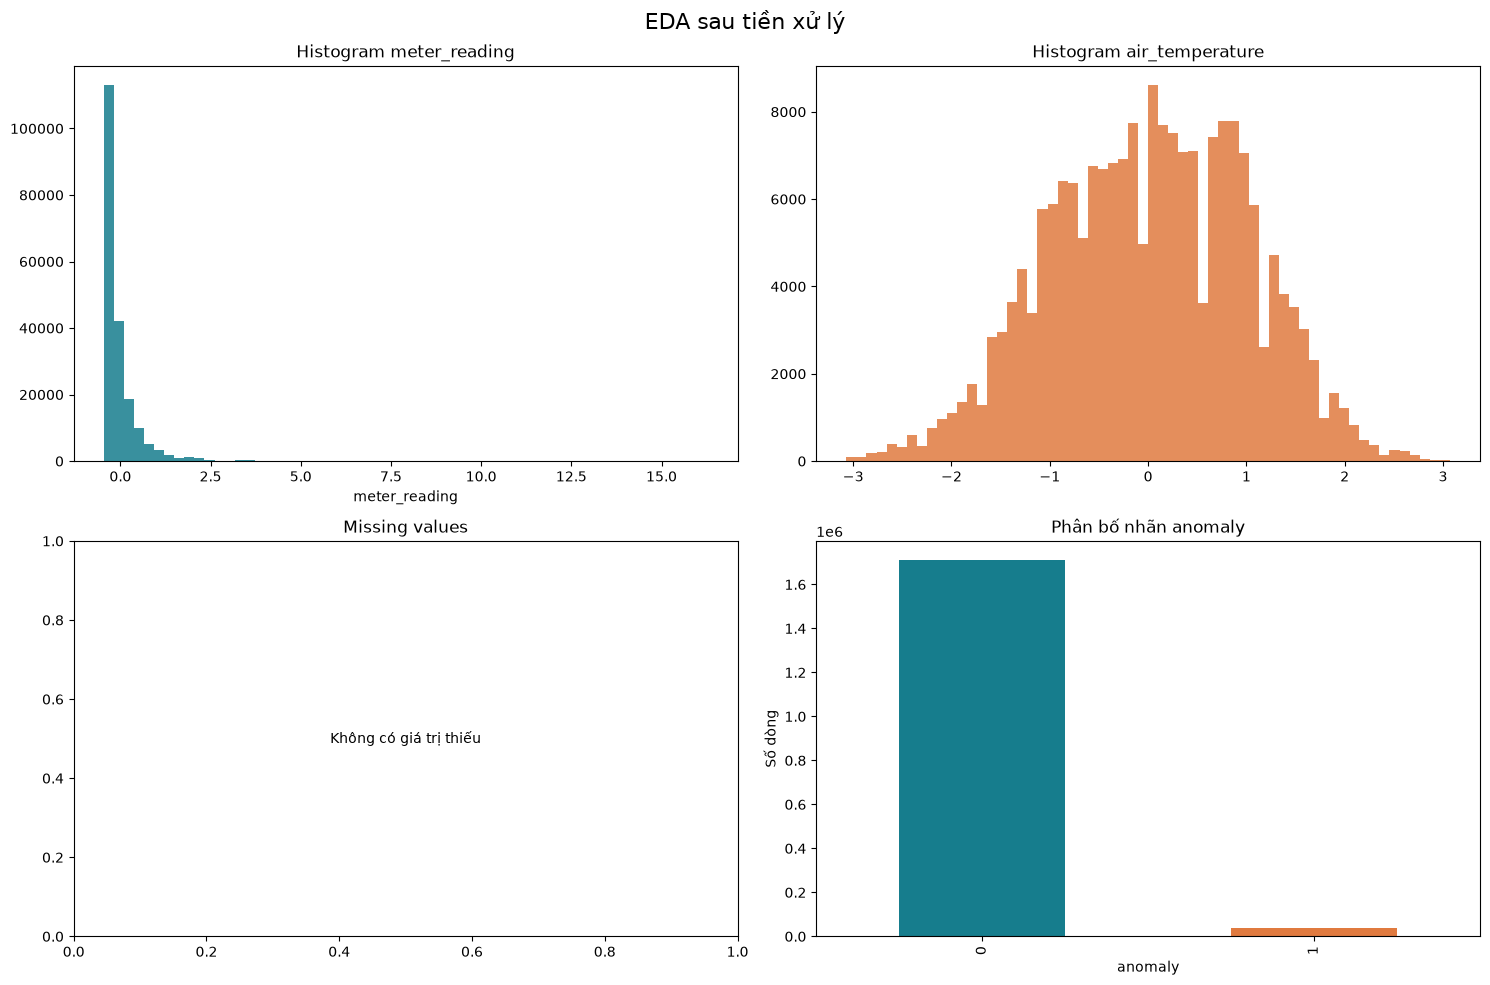

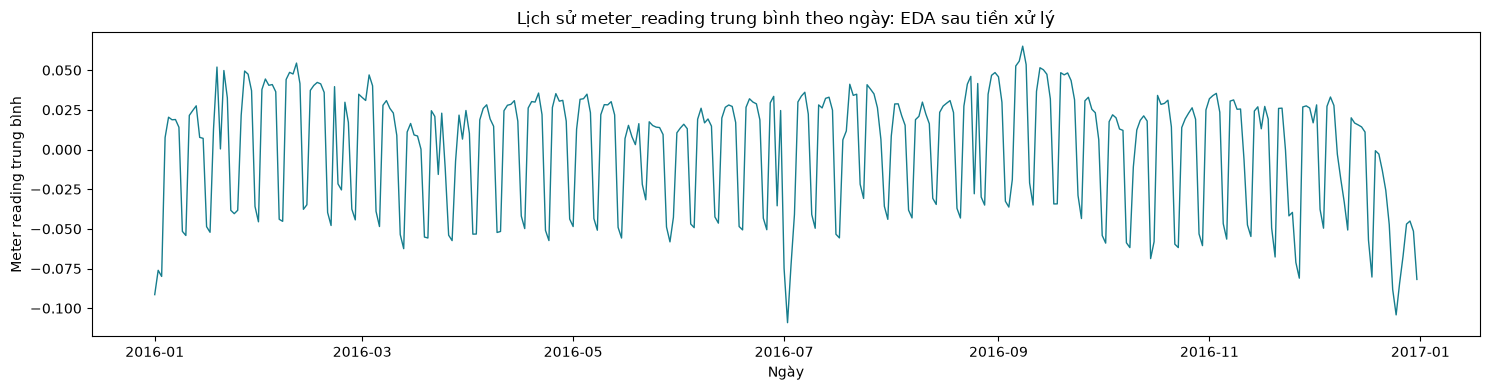

Missing sau xử lý: train=0, test=0
Số dòng train/test sau xử lý: 1,749,494 / 1,800,567


In [15]:
eda_columns = [column for column in  # Chọn một nhóm cột gọn, đủ để xem phân phối và xu hướng.
               ("timestamp", "meter_reading", "air_temperature", "square_feet", "wind_speed")  # Thời gian, target đo và vài feature số.
               if column in X_train.columns]  # Bỏ tên cột không có trong nguồn hiện tại.
eda_train = X_train[eda_columns].copy()  # Tạo bản nhỏ để vẽ, không sao chép toàn bộ X.
eda_train[TARGET] = y_train.to_numpy()  # Gắn nhãn vào bản EDA để so phân bố anomaly.
plot_eda_snapshot(eda_train, "EDA sau tiền xử lý")  # Vẽ lại histogram, missing/class chart và lịch sử ngày.

print(f"Missing sau xử lý: train={int(X_train.isna().sum().sum()):,}, "  # Đếm null toàn ma trận train.
      f"test={int(X_test.isna().sum().sum()):,}")  # Đếm null toàn ma trận test.
print(f"Số dòng train/test sau xử lý: {len(X_train):,} / {len(X_test):,}")  # So với số dòng baseline.
record_step("EDA sau tiền xử lý (không biến đổi dữ liệu)", len(X_train), len(X_train),  # EDA chỉ quan sát, không đổi train.
            len(X_test), len(X_test))  # Ghi test cũng không bị đổi.
del eda_train  # Giải phóng bản sao EDA sau khi vẽ.

## BƯỚC 16: Xuất Parquet tiền xử lý và lưu nhật ký thay đổi.

In [16]:
TRAIN_PQ = PROCESSED_DIR / "train_preprocessed.parquet"
TEST_PQ = PROCESSED_DIR / "test_preprocessed.parquet"

if 'timestamp' in X_train.columns:
    X_train.drop(columns='timestamp', inplace=True)
if 'timestamp' in X_test.columns:
    X_test.drop(columns='timestamp', inplace=True)

train_output = X_train.copy(deep=False)
train_output[TARGET] = y_train.to_numpy()
test_output = X_test.copy(deep=False)
if test_row_ids is not None:
    test_output.insert(0, "row_id", test_row_ids.to_numpy())

# Downcast float64 to float32 to save space and memory
float64_cols = train_output.select_dtypes(include=['float64']).columns
train_output[float64_cols] = train_output[float64_cols].astype('float32')
test_float64_cols = test_output.select_dtypes(include=['float64']).columns
test_output[test_float64_cols] = test_output[test_float64_cols].astype('float32')

train_output.to_parquet(TRAIN_PQ, index=False, engine="fastparquet")
test_output.to_parquet(TEST_PQ, index=False, engine="fastparquet")

train_saved_rows = len(pd.read_parquet(TRAIN_PQ, engine="fastparquet", columns=[TARGET]))
test_saved_rows = len(pd.read_parquet(TEST_PQ, engine="fastparquet", columns=[test_output.columns[0]]))

assert train_saved_rows == len(X_train), "Sai số dòng trong train Parquet."
assert test_saved_rows == len(X_test), "Sai số dòng trong test Parquet."

record_step("Xuất Parquet (giảm dung lượng)", len(X_train), len(X_train),
            len(X_test), len(X_test))
print(f"Train Parquet: {TRAIN_PQ} | {train_saved_rows:,} dòng | "
      f"{TRAIN_PQ.stat().st_size / 1024**2:.1f} MB")
print(f"Test Parquet:  {TEST_PQ} | {test_saved_rows:,} dòng | "
      f"{TEST_PQ.stat().st_size / 1024**2:.1f} MB")

STEP_LOG_TABLE = pd.DataFrame(STEP_LOG)
PREPROCESS_LOG_PATH = PROCESSED_DIR / "preprocessing_step_log.csv"
STEP_LOG_TABLE.to_csv(PREPROCESS_LOG_PATH, index=False)
print(f"\nNhật ký thay đổi: {PREPROCESS_LOG_PATH}")
# Hiển thị log rút gọn có màu sắc
from IPython.display import HTML, display

summary_log = STEP_LOG_TABLE[['step']].copy()
summary_log.rename(columns={'step': 'Bước xử lý'}, inplace=True)

def format_row(added, removed, affected):
    return f"<span style='color:green; font-weight:bold'>+{added}</span> / " \
           f"<span style='color:red; font-weight:bold'>-{removed}</span> / " \
           f"<span style='color:blue; font-weight:bold'>~{affected}</span>"

summary_log['Train (Thêm / Xóa / Chỉnh)'] = STEP_LOG_TABLE.apply(
    lambda r: format_row(r['train_rows_added'], r['train_rows_removed'], r['train_rows_affected']), axis=1
)
summary_log['Test (Thêm / Xóa / Chỉnh)'] = STEP_LOG_TABLE.apply(
    lambda r: format_row(r['test_rows_added'], r['test_rows_removed'], r['test_rows_affected']), axis=1
)

if 'columns_added' in STEP_LOG_TABLE.columns:
    summary_log['Biến động Cột'] = STEP_LOG_TABLE['columns_added'].apply(
        lambda x: f"<span style='color:green; font-weight:bold'>+{x}</span>" if x > 0 else 
                  (f"<span style='color:red; font-weight:bold'>{x}</span>" if x < 0 else 
                   "<span style='color:gray'>0</span>")
    )

html_table = summary_log.to_html(escape=False, index=False)
display(HTML(html_table))

Train Parquet: /home/toon/p4aids/data/processed/train_preprocessed.parquet | 1,749,494 dòng | 31.8 MB
Test Parquet:  /home/toon/p4aids/data/processed/test_preprocessed.parquet | 1,800,567 dòng | 38.7 MB

Nhật ký thay đổi: /home/toon/p4aids/data/processed/preprocessing_step_log.csv


Bước xử lý,Train (Thêm / Xóa / Chỉnh),Test (Thêm / Xóa / Chỉnh),Biến động Cột
Nạp CSV bằng pandas,+0 / -0 / ~0,+0 / -0 / ~0,0
EDA ban đầu (không biến đổi dữ liệu),+0 / -0 / ~0,+0 / -0 / ~0,0
Tách nhãn và row_id,+0 / -0 / ~0,+0 / -0 / ~0,0
Chuẩn hóa timestamp (giữ để feature engineering),+0 / -0 / ~1749494,+0 / -0 / ~1800567,0
Đồng bộ cột train/test,+0 / -0 / ~0,+0 / -0 / ~0,0
Loại bỏ feature thừa & thêm cờ missing,+0 / -0 / ~1749494,+0 / -0 / ~1800567,-18
Tạo đặc trưng chu kỳ (sin/cos) cho thời gian,+0 / -0 / ~1749494,+0 / -0 / ~1800567,+3
Điền thiếu numeric bằng nội suy theo building/timestamp,+0 / -0 / ~107653,+0 / -0 / ~94864,0
Lọc ngoại lai (Outlier) bằng Median,+0 / -0 / ~759868,+0 / -0 / ~765652,0
Chuẩn hóa dữ liệu (Z-score Normalization),+0 / -0 / ~1749494,+0 / -0 / ~1800567,0


## BƯỚC 17: Tổng kết các Feature cuối cùng
Hiển thị danh sách toàn bộ các cột dữ liệu còn lại sau khi tiền xử lý và giải thích ý nghĩa của từng cột.

In [17]:
import pandas as pd

# --- DANH SÁCH BIẾN GIỮ LẠI ---
column_details = {
    'building_id': ('Định tính', 'Mã định danh duy nhất cho từng tòa nhà (sẽ dùng để chia GroupKFold, không dùng để dự đoán).'),
    'timestamp': ('Thời gian', 'Thời gian ghi nhận dữ liệu (mức giờ).'),
    'meter_reading': ('Định lượng', 'Chỉ số tiêu thụ điện năng/nước/gas/năng lượng (đã được nội suy nếu thiếu).'),
    'site_id': ('Định tính', 'Mã khu vực đặt tòa nhà.'),
    'primary_use': ('Định tính', 'Mục đích sử dụng chính của tòa nhà (ví dụ: Education, Office...).'),
    'square_feet': ('Định lượng', 'Tổng diện tích sàn của tòa nhà.'),
    'year_built': ('Định lượng', 'Năm tòa nhà được xây dựng.'),
    'floor_count': ('Định lượng', 'Số tầng của tòa nhà.'),
    'air_temperature': ('Định lượng', 'Nhiệt độ không khí.'),
    'cloud_coverage': ('Định lượng', 'Độ che phủ của mây.'),
    'dew_temperature': ('Định lượng', 'Nhiệt độ điểm sương.'),
    'precip_depth_1_hr': ('Định lượng', 'Lượng mưa trong 1 giờ.'),
    'sea_level_pressure': ('Định lượng', 'Áp suất khí quyển tại mực nước biển.'),
    'wind_direction': ('Định lượng', 'Hướng gió.'),
    'wind_speed': ('Định lượng', 'Tốc độ gió.'),
    'air_temperature_mean_lag7': ('Định lượng', 'Nhiệt độ không khí trung bình trong 7 giờ qua.'),
    'air_temperature_max_lag7': ('Định lượng', 'Nhiệt độ không khí cao nhất trong 7 giờ qua.'),
    'air_temperature_min_lag7': ('Định lượng', 'Nhiệt độ không khí thấp nhất trong 7 giờ qua.'),
    'air_temperature_std_lag7': ('Định lượng', 'Độ lệch chuẩn nhiệt độ không khí trong 7 giờ qua.'),
    'air_temperature_mean_lag73': ('Định lượng', 'Nhiệt độ không khí trung bình trong 73 giờ qua (~3 ngày).'),
    'air_temperature_max_lag73': ('Định lượng', 'Nhiệt độ không khí cao nhất trong 73 giờ qua.'),
    'air_temperature_min_lag73': ('Định lượng', 'Nhiệt độ không khí thấp nhất trong 73 giờ qua.'),
    'air_temperature_std_lag73': ('Định lượng', 'Độ lệch chuẩn nhiệt độ không khí trong 73 giờ qua.'),
    'hour_sin': ('Định lượng', 'Thành phần X (cos) của biến Giờ trong ngày (để học tính chu kỳ).'),
    'hour_cos': ('Định lượng', 'Thành phần Y (sin) của biến Giờ trong ngày.'),
    'month_sin': ('Định lượng', 'Thành phần X của biến Tháng trong năm.'),
    'month_cos': ('Định lượng', 'Thành phần Y của biến Tháng trong năm.'),
    'weekday_sin': ('Định lượng', 'Thành phần X của biến Thứ trong tuần.'),
    'weekday_cos': ('Định lượng', 'Thành phần Y của biến Thứ trong tuần.'),
    'is_holiday': ('Định tính', 'Cờ nhị phân (0/1) đánh dấu ngày nghỉ lễ.'),
    'gte_hour': ('Định lượng', 'Giá trị target (anomaly) mã hóa trung bình (Target Encoding) theo Giờ.'),
    'gte_weekday': ('Định lượng', 'Giá trị target mã hóa trung bình theo Thứ.'),
    'gte_month': ('Định lượng', 'Giá trị target mã hóa trung bình theo Tháng.'),
    'gte_primary_use': ('Định lượng', 'Giá trị target mã hóa trung bình theo Mục đích sử dụng.'),
    'gte_site_id': ('Định lượng', 'Giá trị target mã hóa trung bình theo Khu vực.'),
    'gte_meter_hour': ('Định lượng', 'Giá trị target mã hóa trung bình theo tổ hợp Loại đồng hồ + Giờ.'),
    'gte_meter_weekday': ('Định lượng', 'Giá trị target mã hóa trung bình theo Loại đồng hồ + Thứ.'),
    'gte_meter_month': ('Định lượng', 'Giá trị target mã hóa trung bình theo Loại đồng hồ + Tháng.'),
    'gte_meter_primary_use': ('Định lượng', 'Giá trị target mã hóa trung bình theo Loại đồng hồ + Mục đích sử dụng.'),
    'gte_meter_site_id': ('Định lượng', 'Giá trị target mã hóa trung bình theo Loại đồng hồ + Khu vực.'),
    'meter_reading_was_missing': ('Định tính', 'Cờ nhị phân (0/1) cho biết chỉ số đo lường ban đầu bị khuyết.'),
    'anomaly': ('Định tính', 'Nhãn mục tiêu (1 = bất thường, 0 = bình thường) - Chỉ tồn tại ở tập train.')
}

final_columns = X_train.columns.tolist() + [TARGET]

# Thêm mô tả cho các cột One-Hot Encoding tự động sinh ra
for col in final_columns:
    if col.startswith('primary_use_') and col not in column_details:
        column_details[col] = ('Định tính', 'Đặc trưng mã hóa One-Hot Encoding (trị số 0/1) tách ra từ biến category có số lượng nhóm vừa phải.')
    elif col.startswith('meter_') and 'missing' not in col and col not in column_details:
        column_details[col] = ('Định tính', 'Đặc trưng mã hóa One-Hot (0/1) cho loại đồng hồ đo lường.')
    elif col.startswith('site_id_') and col not in column_details:
        column_details[col] = ('Định lượng', 'Đặc trưng mã hóa Frequency Encoding (tần suất) cho ID khu vực.')
    elif col.startswith('building_id_') and col not in column_details:
        column_details[col] = ('Định lượng', 'Đặc trưng mã hóa Frequency Encoding (tần suất xuất hiện) cho ID tòa nhà.')


print("="*60)
print(f"1. CÁC BIẾN CÒN GIỮ LẠI (Tổng số: {len(final_columns)} cột)")
print("="*60)
summary_df = pd.DataFrame({
    'Tên Cột': final_columns,
    'Loại Biến': [column_details.get(col, ('Khác', ''))[0] for col in final_columns],
    'Ý Nghĩa': [column_details.get(col, ('', 'Chưa có mô tả'))[1] for col in final_columns]
})

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 150)
display(summary_df)

# --- DANH SÁCH BIẾN BỊ LOẠI BỎ ---
dropped_details = [
    ('timestamp', 'Định lượng (Thời gian)', 'Thời điểm thu thập dữ liệu.', 'Đã được chuyển hóa thành các biến chu kỳ (sin/cos). Xóa bỏ để mô hình Deep Learning/Tree không bị nhiễu do khác biệt định dạng.'),
    ('year', 'Định lượng', 'Năm thu thập dữ liệu.', 'Biến hằng số (chỉ có duy nhất 1 năm cho mọi dòng dữ liệu). Không mang thông tin phân loại hay dự đoán nên vô giá trị.'),
    ('gte_meter', 'Định lượng', 'Target encoding của loại đồng hồ.', 'Biến hằng số (phương sai = 0). Mô hình không thể học được từ cột mà dữ liệu luôn luôn giống nhau.'),
    
    
    
    ('hour', 'Định lượng', 'Giờ trong ngày (0-23).', 'Đã được tách hóa thành 2 biến lượng giác (hour_sin, hour_cos).'),
    ('weekday', 'Định lượng', 'Thứ trong tuần.', 'Đã biến đổi vòng tròn thành weekday_sin, weekday_cos.'),
    ('month', 'Định lượng', 'Tháng trong năm.', 'Đã biến đổi vòng tròn thành month_sin, month_cos.'),
    ('hour_x', 'Định lượng', 'Tọa độ X của Giờ.', 'Xóa bỏ bản cũ để thay bằng bản sin/cos chuẩn xác hơn.'),
    ('hour_y', 'Định lượng', 'Tọa độ Y của Giờ.', 'Xóa bỏ bản cũ để thay bằng bản sin/cos chuẩn xác hơn.'),
    ('weekday_x', 'Định lượng', 'Tọa độ X của Thứ.', 'Xóa bỏ bản cũ để thay bằng bản sin/cos chuẩn xác hơn.'),
    ('weekday_y', 'Định lượng', 'Tọa độ Y của Thứ.', 'Xóa bỏ bản cũ để thay bằng bản sin/cos chuẩn xác hơn.'),
    ('month_x', 'Định lượng', 'Tọa độ X của Tháng.', 'Xóa bỏ bản cũ để thay bằng bản sin/cos chuẩn xác hơn.'),
    ('month_y', 'Định lượng', 'Tọa độ Y của Tháng.', 'Xóa bỏ bản cũ để thay bằng bản sin/cos chuẩn xác hơn.'),
    ('weekday_hour', 'Định tính', 'Tổ hợp ngày trong tuần và giờ.', 'Thông tin trùng lặp vì đã có các biến gốc giờ và thứ.'),
    ('building_weekday_hour', 'Định tính', 'Tổ hợp tòa nhà, ngày, và giờ.', '100% tòa nhà trong tập test là tòa nhà hoàn toàn MỚI, chưa từng xuất hiện trong tập train. Việc cho mô hình học các ID liên quan trực tiếp đến tòa nhà sẽ gây ra Overfitting nghiêm trọng.'),
    ('building_weekday', 'Định tính', 'Tổ hợp tòa nhà và thứ.', 'Lý do giống building_weekday_hour: Không thể dự đoán vì tập test toàn là ID mới.'),
    ('building_month', 'Định tính', 'Tổ hợp tòa nhà và tháng.', 'Lý do giống building_weekday_hour.'),
    ('building_hour', 'Định tính', 'Tổ hợp tòa nhà và giờ.', 'Lý do giống building_weekday_hour.'),
    ('building_meter', 'Định tính', 'Tổ hợp tòa nhà và loại đồng hồ.', 'Lý do giống building_weekday_hour.'),
    ('gte_building_id', 'Định lượng', 'Target encoding theo tòa nhà.', 'Bản chất xuất phát từ việc rò rỉ ID tòa nhà cụ thể, gây distribution shift 100% trên tập test. Bắt buộc bỏ.'),
    ('gte_meter_building_id', 'Định lượng', 'Target encoding theo loại đồng hồ + tòa nhà.', 'Như trên, liên quan đến tính đặc thù ID tòa nhà tập train.'),
    ('gte_meter_building_id_hour', 'Định lượng', 'Target encoding theo đồng hồ, tòa nhà, giờ.', 'Như trên.'),
    ('gte_meter_building_id_weekday', 'Định lượng', 'Target encoding theo đồng hồ, tòa nhà, thứ.', 'Như trên.'),
    ('gte_meter_building_id_month', 'Định lượng', 'Target encoding theo đồng hồ, tòa nhà, tháng.', 'Như trên.')
]

print("\n" + "="*60)
print(f"2. CÁC BIẾN BỊ LOẠI BỎ Ở TIỀN XỬ LÝ (Tổng số: {len(dropped_details)} cột)")
print("="*60)

dropped_df = pd.DataFrame(dropped_details, columns=['Tên Cột', 'Loại Biến', 'Ý Nghĩa Gốc', 'Lý do bị loại bỏ (QUAN TRỌNG)'])
display(dropped_df)



1. CÁC BIẾN CÒN GIỮ LẠI (Tổng số: 53 cột)


,Tên Cột,Loại Biến,Ý Nghĩa
0,building_id,Định tính,"Mã định danh duy nhất cho từng tòa nhà (sẽ dùng để chia GroupKFold, không dùng để dự đoán)."
1,meter_reading,Định lượng,Chỉ số tiêu thụ điện năng/nước/gas/năng lượng (đã được nội suy nếu thiếu).
2,site_id,Định tính,Mã khu vực đặt tòa nhà.
3,square_feet,Định lượng,Tổng diện tích sàn của tòa nhà.
4,year_built,Định lượng,Năm tòa nhà được xây dựng.
5,floor_count,Định lượng,Số tầng của tòa nhà.
6,air_temperature,Định lượng,Nhiệt độ không khí.
7,cloud_coverage,Định lượng,Độ che phủ của mây.
8,dew_temperature,Định lượng,Nhiệt độ điểm sương.
9,precip_depth_1_hr,Định lượng,Lượng mưa trong 1 giờ.



2. CÁC BIẾN BỊ LOẠI BỎ Ở TIỀN XỬ LÝ (Tổng số: 23 cột)


,Tên Cột,Loại Biến,Ý Nghĩa Gốc,Lý do bị loại bỏ (QUAN TRỌNG)
0,timestamp,Định lượng (Thời gian),Thời điểm thu thập dữ liệu.,Đã được chuyển hóa thành các biến chu kỳ (sin/cos). Xóa bỏ để mô hình Deep Learning/Tree không bị nhiễu do khác biệt định dạng.
1,year,Định lượng,Năm thu thập dữ liệu.,Biến hằng số (chỉ có duy nhất 1 năm cho mọi dòng dữ liệu). Không mang thông tin phân loại hay dự đoán nên vô giá trị.
2,gte_meter,Định lượng,Target encoding của loại đồng hồ.,Biến hằng số (phương sai = 0). Mô hình không thể học được từ cột mà dữ liệu luôn luôn giống nhau.
3,hour,Định lượng,Giờ trong ngày (0-23).,"Đã được tách hóa thành 2 biến lượng giác (hour_sin, hour_cos)."
4,weekday,Định lượng,Thứ trong tuần.,"Đã biến đổi vòng tròn thành weekday_sin, weekday_cos."
5,month,Định lượng,Tháng trong năm.,"Đã biến đổi vòng tròn thành month_sin, month_cos."
6,hour_x,Định lượng,Tọa độ X của Giờ.,Xóa bỏ bản cũ để thay bằng bản sin/cos chuẩn xác hơn.
7,hour_y,Định lượng,Tọa độ Y của Giờ.,Xóa bỏ bản cũ để thay bằng bản sin/cos chuẩn xác hơn.
8,weekday_x,Định lượng,Tọa độ X của Thứ.,Xóa bỏ bản cũ để thay bằng bản sin/cos chuẩn xác hơn.
9,weekday_y,Định lượng,Tọa độ Y của Thứ.,Xóa bỏ bản cũ để thay bằng bản sin/cos chuẩn xác hơn.
